In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Se parte de un dataset previamente limpio y procesado, proporcionado por el equipo de trabajo.

In [2]:
df = pd.read_csv("Algerian_forest_fires_dataset_CLEANED.csv")

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
df_cluster = df.drop(columns=["day", "month", "year", "Classes"])
df_cluster.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0


In [5]:
df_cluster.describe()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


# Escalamiento de datos

### Se aplica normalización para que todas las variables tengan la misma importancia en el cálculo de distancias del algoritmo K-Means.

In [6]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

# Método del codo

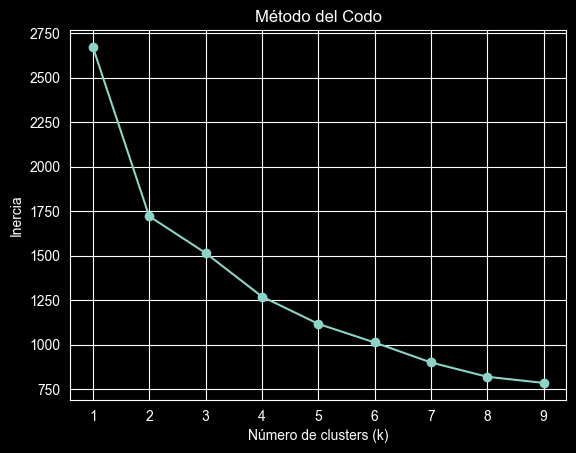

In [7]:
inertia = []

k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

### Se busca el punto donde la curva de bajar de forma brusca.

# Silhouette Score

In [9]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    print(f"k = {k}, Silhouette Score = {score}")

k = 2, Silhouette Score = 0.30802091438283685
k = 3, Silhouette Score = 0.30306501472293224
k = 4, Silhouette Score = 0.2104889961574371
k = 5, Silhouette Score = 0.20782069570137657
k = 6, Silhouette Score = 0.20026593372081838
k = 7, Silhouette Score = 0.22295181664874872
k = 8, Silhouette Score = 0.23309118993324174
k = 9, Silhouette Score = 0.19004973300584976


### El valor más alto indica mejor separación entre clusters.
### Se usa junto con el método del codo.

### Para determinar el número óptimo de clusters, se aplicó el método del codo, donde se observó una disminución significativa de la inercia hasta k = 3, a partir del cual la mejora se vuelve menos pronunciada.

### Adicionalmente, se utilizó el Silhouette Score como métrica de validación, obteniendo el valor más alto para k = 2 (0.308), lo que indica una mejor separación y cohesión de los grupos.

### Por lo tanto, se selecciona k = 2 como el número óptimo de clusters, ya que ofrece el mejor equilibrio entre simplicidad del modelo y calidad de agrupamiento.